Unit07 original script: Author: Dr Mike Lakoju, CardiffMet
### Author: Dr Mike Lakoju

**Reflection:** 

The exercises progressively demonstrated how an artificial neuron produces an output, how a perceptron learns through weight adjustment, and how hidden layers and backpropagation enable an MLP to model more complex nonlinear relationships.

* **Architecture:** 2 inputs → 3 hidden neurons → 1 output

* **Forward propagation:** information moves forward to produce a prediction

* **Activation:** sigmoid introduces a smooth, non-linear transformation

* **Backpropagation:** prediction error is propagated backwards to determine how the weights should change

* **Training:** repeatedly updating weights over many epochs reduces prediction error

ANN FLOW:

* **FORWARD PROPAGATION:** Input → weighted sum → Hidden layer → weighted sum → Output

* **Compare with actual y:** Prediction → Error

* **BACKPROPAGATION:** Output error → Output delta → Hidden delta → Update hidden→ Output weights → Update input→hidden weights

* **Repeat:** Next epoch → repeat learning process → progressively minimise error

There is an iterative process happening behind **model.fit(X_train, y_train)** The network learns by repeatedly propagating information forward to make a prediction and propagating the resulting error backward to adjust its weights.

## 1. Simple Perceptron: Understanding the artificial neuron
Explores how inputs and weights are combined through a weighted sum and step activation function to produce a binary output.

A perceptron combines numerical inputs using weights that determine each input’s influence. It sums the weighted inputs and passes them through an activation function, which determines the output “fired” (1) or not (0). Changing the weights changes the neuron’s response. During training these weights are learned rather than manually selected. The sign of weights tells the direction of influence, whereas the magnitude tells the strength of influence. The perceptron, works as a threshold function that provides a linear binary classifier.

**What does a neuron do?**
* Calculates weighted sum → activation → output

**How does the neuron learn?**
* Prediction → compare with known answer → error → adjust weights → repeat


In [272]:
# Import Library
import numpy as np

With NumPy, we work with arrays. Hence, we will need to define our inputs as arrays.

- This is information entering the neuron: inputs [45, 25] and weights [0.7, 0.1]. 
- The weights tell the perceptron how strongly each input should influence its decision.
- Inputs provide information, weights determine the influence of that information on the neuron

In [273]:
# Define the Inputs and weights
inputs = np.array([45, 25])

In [274]:
# Check the type of the inputs
type(inputs)

numpy.ndarray

In [275]:
#Define the weights
# creating the weights as Numpy array

weights = np.array([0.7, 0.1])

In [276]:
# Check the value at index 0 
weights[0]

np.float64(0.7)

### Create the Sum Function

The dot function is called the dot product from linear algebra. 

* the dot() is calculating (45x0.7 + 25x0.1). The weighted sum is the signal arriving at the neuron.
* The neuron still needs to make decision. Here is where the step function comes in.


In [277]:
def sum_func(inputs, weights):
    return inputs.dot(weights)

In [278]:
# for weights = [0.7, 0.1]

s_prob1 = sum_func(inputs, weights)
s_prob1 

np.float64(34.0)

### Create Step function
Step function helps neuron make a decision. The threshold for weighted sum => 1, otherwise < 1 => 0
This is the activation function with neuron asking, whether a combined signal is stroing enoough to activate. 
- if Yes -> 1
- if No -> 0

In [279]:
def step_function(sum_func):
  if (sum_func >= 1):
    print(f'The Sum Function is greater than or equal to 1')
    return 1
  else:
        print(f'The Sum Function is NOT greater')
        return 0

In [280]:
### Result

step_function(s_prob1 )

The Sum Function is greater than or equal to 1


1

 ### If the is weights = [- 0.7, 0.1]

Let's compare the weights. The positive weights pushes the weighted sum forward and a negative one, downwards. Changing the weights changes how the nueron respond to exactly the same input. 

In [281]:
# for weights = [- 0.7, 0.1]

weights = [-0.7, 0.1]

s_prob2 = sum_func(inputs, weights)

round(s_prob2, 2)  #round to 2 decimal places

np.float64(-29.0)

In [282]:
# Results
step_function(s_prob2 )

The Sum Function is NOT greater


0

In [283]:
## If the is weights = [2.5, -3.0]
weights = [2.5, -3.0]

s_prob3 = sum_func(inputs, weights)

round(s_prob3, 2)  

np.float64(37.5)

In [284]:
# Results
step_function(s_prob3 )

The Sum Function is greater than or equal to 1


1

### By changing the input values and weights observe different results
This is fundamental to ANN, during the learning process the weights get adjusted to reduce prediction error.

## 2. AND Operator: From weights initialisation to learning through weight updates

Extends the perceptron by introducing labelled examples, prediction error, learning rate and iterative weight updates.

How neuron learnes the weights: 
* Input 
* Prediction 
* Compare with correct answer
* Error 
* Update weights 
* Repeat 
* Weights capable of representing AND

In [285]:
# Inputs (training data)
# Creating input values as a matrix not as a vector
inputs = np.array([[0,0], [0,1], [1,0], [1,1]])

In [286]:
# Checking the shape of the inputs
inputs.shape

(4, 2)

In [287]:
# Outputs
outputs = np.array([0, 0, 0, 1])

In [288]:
#Checking the shape of the outputs
outputs.shape

(4,)

In [289]:
# Weights: one weight for x1 and one for x2  
weights = np.array([0.0, 0.0])

In [290]:
# Learning Rate
learning_rate = 0.1

* The learning rate controls how large each adjustment is.

In [291]:
## Step function
# This is our Activation function

def step_function(sum):
  if (sum >= 1):
    #print(f'The Sum of Weights is Greater or equal to 1')
    return 1
  else:
        #print(f'The Sum of Weights is NOT > or = to 1')
        return 0

### Process Output
<b>We define a function that allows us to calculate/ process the output. The function accepts an instance of our data, then calculate the sum function using Numpy. Finally, we check the output by passing it through the "Step Function."</b>

We are making a prediction, based on the same question: Given the current weights, what is the prediction?

In [292]:
# Process Output 
def cal_output(instance):
  sum_func = instance.dot(weights)
  return step_function(sum_func)


In [293]:
# Pass it as a list in a numpy array
cal_output(np.array([[1,1]]))

0

### Train

In [294]:
# Check the number of outputs 

len(outputs)

4

In [295]:
# Checking the index of the input at postion 3 .. 
# this is the last inpute value
inputs[3]

array([1, 1])

In [296]:
inputs

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

<b>Note that:</b> usually, we will need to define the number of epochs, because we will never really get a value of zero when dealing with real-world data. However, for this small data, we will run the loop till we obtain zero error

In [297]:
def train():
    #
    total_error_value = 1
    # While the total_error_value is not equal to zero. we are asumming that at the start of running our network there will be no zero
    while (total_error_value != 0):
        #making the total_error 0 so we can do other calculations
        total_error_value = 0
        #Looping into each row of the dataset (remember indexing in python starts at zero hence 0-3 which are 4 values)
        for i in range(len(outputs)):
            #Calculating predictions
            prediction = cal_output(inputs[i])
            # Calculating the absolute value of the error
            error = abs(outputs[i] - prediction)
            #Updating the error
            total_error_value  += error
            
            if error > 0:
                for j in range(len(weights)):
                    #updating the weights for x1 and x2
                    weights[j] = weights[j] + (learning_rate * inputs[i][j] * error)
                    print('Weight updated to: ' + str(weights[j]))
        print('Total error Value: ' + str(total_error_value))

In [298]:
train()

Weight updated to: 0.1
Weight updated to: 0.1
Total error Value: 1
Weight updated to: 0.2
Weight updated to: 0.2
Total error Value: 1
Weight updated to: 0.30000000000000004
Weight updated to: 0.30000000000000004
Total error Value: 1
Weight updated to: 0.4
Weight updated to: 0.4
Total error Value: 1
Weight updated to: 0.5
Weight updated to: 0.5
Total error Value: 1
Total error Value: 0


### Classification
After the training, we used the learned weights.

In [299]:
# Now we have the final weights that will be used to classify new instances of the data after training. 

weights

array([0.5, 0.5])

In [300]:
cal_output(np.array([0,0]))

0

In [301]:
cal_output(np.array([0,1]))

0

In [302]:
cal_output(np.array([1,0]))

0

In [303]:
cal_output(np.array([1,1]))

1

# 3. Multilayer Perceptor / Multi-Layer Neural Networks: XOR

Moving from simples structure Input / Output to moe complex one where the connection between neurons is defined. Hier several intermediary neurons are set to form a hidden layer.

Introduces a hidden layer, sigmoid activation, forward propagation and backpropagation to solve the nonlinear XOR problem.

- XOR operator, returns: 1) TRUE if either statement is TRUE, 2) FALSE if both statements are TRUE and If neither is TRUE.
- Unlike AND, XOR cannot be separated with one simple linear decision boundary, hence single perceptron isn’t enough.

Example: 
* 2 input features
* 3 hidden neurons
* 1 output neuron


**ANN TRAINING**
* **FORWARD PROPAGATION:** Input → weighted sum → Hidden layer → weighted sum → Output

* **Compare with actual y:** Prediction → Error

* **BACKPROPAGATION:** Output error → Output delta → Hidden delta → Update hidden→ Output weights → Update input→hidden weights

* **Repeat:** Next epoch → repeat learning process → progressively minimise error

There is an iterative process happening behind **model.fit(X_train, y_train)** The network learns by repeatedly propagating information forward to make a prediction and propagating the resulting error backward to adjust its weights.

### Define the Sigmoid Function

    * If X is high, the value is approximately 1
    * if X is small, the value is approximately 0

In [304]:
def sigmoid(sum_func):
  return 1 / (1 + np.exp(-sum_func))

In [305]:
sigmoid(0)

np.float64(0.5)

In [306]:
np.exp(2)

np.float64(7.38905609893065)

In [307]:
np.exp(1)

np.float64(2.718281828459045)

In [308]:
sigmoid(40)

np.float64(1.0)

In [309]:
sigmoid(-20.5)

np.float64(1.2501528648238605e-09)

### Input Layer to Hidden Layer
Define "Inputs, outputs and weights" as Numpy arrays

In [310]:
# Inputs
inputs = np.array([[0,0],
                   [0,1],
                   [1,0],
                   [1,1]])

inputs

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [311]:
inputs.shape

(4, 2)

In [312]:
# Outputs
outputs = np.array([[0],
                    [1],
                    [1],
                    [0]])

In [313]:
outputs.shape

(4, 1)

### Weights: These weights are for the connection between the inputs and the hidden layer

In [314]:
# Weights
# First row holds the weights for x1, 2nd row contains the weights for x2

weights_0 = np.array([[-0.424, -0.740, -0.961],
                     [0.358, -0.577, -0.469]])
weights_0.shape

(2, 3)

In [315]:
weights_1 = np.array([[-0.017],
                     [-0.893],
                     [0.148]])
weights_1.shape

(3, 1)

### Epochs & Learning Rate

In [316]:
epochs = 100
learning_rate = 0.3

In [317]:
#for epoch in epochs:

In [318]:
input_layer = inputs
input_layer

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

## 1. Forward propagation
**Inputs → weighted sums → sigmoid → hidden layer (hidden-neuron activations)**

Pass inputs through the network using the current weights to generate a prediction.

In [319]:
# "sum_synapse_0" This holds the sum function total of weights for the hidden layer
# For the Output: Each row holds the sum_func for each input data  [0,0,0 -> data 0,0],[0.358, -0.577, -0.469 --> 0,1]
# The dot product does the matrix multiplication and also the sum

sum_synapse_0 = np.dot(input_layer, weights_0)
sum_synapse_0

array([[ 0.   ,  0.   ,  0.   ],
       [ 0.358, -0.577, -0.469],
       [-0.424, -0.74 , -0.961],
       [-0.066, -1.317, -1.43 ]])

In [320]:
# Computing the Sigmoid function for the Hidden layer

hidden_layer = sigmoid(sum_synapse_0)
hidden_layer

array([[0.5       , 0.5       , 0.5       ],
       [0.5885562 , 0.35962319, 0.38485296],
       [0.39555998, 0.32300414, 0.27667802],
       [0.48350599, 0.21131785, 0.19309868]])

Why sigmoid instead of the step function?

* weighted sum ≥ 1 → 1, otherwise → 0
* Sigmoid instead gives a smooth output: 
** sigma(0)=0.5
** sigma(40)=1
** sigma(-20.5)=0

Sigmoid is differentiable. It helps calculate how its output changes, which allows errors to be propagated backwards to adjust the weights.

Dealing with the 2nd side

In [321]:
weights_1

array([[-0.017],
       [-0.893],
       [ 0.148]])

Journey: X → weights₀ → sigmoid → hidden layer → weights₁ → sigmoid → prediction

In [322]:
# "sum_synapse_1" This holds the sum function total of weights for the output layer
# For the Output: Each row holds the sum_func for each input data

sum_synapse_1 = np.dot(hidden_layer, weights_1)
sum_synapse_1

array([[-0.381     ],
       [-0.27419072],
       [-0.25421887],
       [-0.16834784]])

In [323]:
output_layer = sigmoid(sum_synapse_1)
output_layer

array([[0.40588573],
       [0.43187857],
       [0.43678536],
       [0.45801216]])

In [324]:
outputs

array([[0],
       [1],
       [1],
       [0]])

In [325]:
output_layer

array([[0.40588573],
       [0.43187857],
       [0.43678536],
       [0.45801216]])

### 2. Calculate error
Compare the network's prediciton with the known target

error_output_layer = outputs - output_layer

**How far is my prediction from the correct answer?**

average_error = np.mean(abs(error_output_layer))
summarises the error across the four XOR examples.

**TRAINING OBJECTIVE : make this error smaller.**


In [326]:
error_output_layer = outputs - output_layer
error_output_layer

array([[-0.40588573],
       [ 0.56812143],
       [ 0.56321464],
       [-0.45801216]])

In [327]:
average_error = np.mean(abs(error_output_layer))
average_error

np.float64(0.49880848923713045)

### 3. Backpropagation
A prediction is made and an error discovered.

**How should the weights throughout the network change to reduce that error?**

Work backwards from the error to determine how the hidden and output layers contributed to it.

Prediction → ERROR → Output layer → weights → Hidden layer → weights₀

Backpropagation starts with the prediction error at the output layer and propagates an error signal backwards through the network. The contribution of the hidden neurons is determined using the connection weights and activation-function derivatives. These error signals are then used with the learning rate to update the network's weights.

In [328]:
def sigmoid_derivative(sigmoid):
    return sigmoid * (1 - sigmoid)

The derivative tells the network how sensitive the neuron’s output is to a change in its input. That information helps determine how much a weight should change.

### 4. Update weights

Adjust the weights using the calculated deltas and learning rate, then repeat the process in the next epoch.

### 5. Calculate output delta

**How wrong was I? × How sensitive is this neuron?**

**Delta = signal used to determine how weights should be adjusted.**

delta_output = error_output_layer * derivative_output

to obtain the adjustment signal for the output layer.



In [329]:
# output_layer holds the results of our application of the sigmoid, computed above

output_layer

array([[0.40588573],
       [0.43187857],
       [0.43678536],
       [0.45801216]])

In [330]:
# derivative_output is our Derivative of the activation function (sigmoid) which we have on the slide
# each row is for each instance of our input dataset

derivative_output = sigmoid_derivative(output_layer)
derivative_output

array([[0.2411425 ],
       [0.24535947],
       [0.24600391],
       [0.24823702]])

In [331]:
error_output_layer

array([[-0.40588573],
       [ 0.56812143],
       [ 0.56321464],
       [-0.45801216]])

In [332]:
# Delta output
# each row is for each instance of our input dataset

delta_output = error_output_layer * derivative_output
delta_output

array([[-0.0978763 ],
       [ 0.13939397],
       [ 0.138553  ],
       [-0.11369557]])

### 6. Send the error backwards to the hidden layer

weights_1T = weights_1.T

delta_output_x_weight = delta_output.dot(weights_1T)

The transpose is largely a matrix-shape requirement here. 

The output error is being distributed backwards through the connections to determine how much the hidden neurons contributed to it.


### Delta calculations for the Hidden Layer

In [333]:
delta_output

array([[-0.0978763 ],
       [ 0.13939397],
       [ 0.138553  ],
       [-0.11369557]])

In [334]:
weights_1

array([[-0.017],
       [-0.893],
       [ 0.148]])

#### NOTE THAT: 
    * Lets deal with this part first (Weight  * delta_output)
    * Notice that we will get an error below becuase of the shape of the weights_1  (Transpose) 

In [335]:
delta_output_x_weight = delta_output.dot(weights_1)

ValueError: shapes (4,1) and (3,1) not aligned: 1 (dim 1) != 3 (dim 0)

In [ ]:
weights_1.shape

(3, 1)

In [339]:
weights_1T = weights_1.T
weights_1T

array([[-0.017, -0.893,  0.148]])

In [340]:
weights_1T.shape

(1, 3)

#### Each one of the weights will have to be multiplied by each delta_output for each data instance     
       
       array([[-0.017],
             [-0.893],
             [ 0.148]])

In [ ]:
delta_output_x_weight = delta_output.dot(weights_1T)
delta_output_x_weight

array([[ 0.0016639 ,  0.08740354, -0.01448569],
       [-0.0023697 , -0.12447882,  0.02063031],
       [-0.0023554 , -0.12372783,  0.02050584],
       [ 0.00193282,  0.10153015, -0.01682694]])

#### NOTE THAT:
    * Now we need to deal with the last part of the equation   
    * sigmoid_derivative * delta_output_x_weight

In [ ]:
hidden_layer

array([[0.5       , 0.5       , 0.5       ],
       [0.5885562 , 0.35962319, 0.38485296],
       [0.39555998, 0.32300414, 0.27667802],
       [0.48350599, 0.21131785, 0.19309868]])

In [ ]:
#  Each row in the output of delta_hidden_layer is for the data input values

delta_hidden_layer = delta_output_x_weight * sigmoid_derivative(hidden_layer)
delta_hidden_layer

array([[ 0.00041597,  0.02185088, -0.00362142],
       [-0.00057384, -0.02866677,  0.00488404],
       [-0.00056316, -0.02705587,  0.00410378],
       [ 0.00048268,  0.01692128, -0.00262183]])

#### We will deal with the (input * delta) first 
* The first column in "hidden_layer" holds  the activation value for the first neuron

In [ ]:
hidden_layer

array([[0.5       , 0.5       , 0.5       ],
       [0.5885562 , 0.35962319, 0.38485296],
       [0.39555998, 0.32300414, 0.27667802],
       [0.48350599, 0.21131785, 0.19309868]])

In [ ]:
delta_output

array([[-0.0978763 ],
       [ 0.13939397],
       [ 0.138553  ],
       [-0.11369557]])

* We need to multiply the "inputs" by "delta" however, for the matrix multiplication we need to transpose the values in the hidden_layer, so we have all of them on one row for each neuron

In [ ]:
hidden_layerT = hidden_layer.T
hidden_layerT

array([[0.5       , 0.5885562 , 0.39555998, 0.48350599],
       [0.5       , 0.35962319, 0.32300414, 0.21131785],
       [0.5       , 0.38485296, 0.27667802, 0.19309868]])

In [ ]:
input_x_delta1 = hidden_layerT.dot(delta_output)
input_x_delta1

array([[0.03293657],
       [0.02191844],
       [0.02108814]])

#### Let us now update the "weights_1"

In [ ]:
weights_1 = weights_1 + (input_x_delta1 * learning_rate)
weights_1

array([[-0.00711903],
       [-0.88642447],
       [ 0.15432644]])

## Dealing with the Hidden Layer to Input Layer

In [ ]:
# First column is X1, and 2nd column is X2 (our input values )

input_layer

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [ ]:
delta_hidden_layer

array([[ 0.00041597,  0.02185088, -0.00362142],
       [-0.00057384, -0.02866677,  0.00488404],
       [-0.00056316, -0.02705587,  0.00410378],
       [ 0.00048268,  0.01692128, -0.00262183]])

In [ ]:
# we need to transpose the values just as we did before

input_layerT = input_layer.T
input_layerT

array([[0, 0, 1, 1],
       [0, 1, 0, 1]])

In [ ]:
input_x_delta0 = input_layerT.dot(delta_hidden_layer)
input_x_delta0

array([[-8.04778516e-05, -1.01345901e-02,  1.48194623e-03],
       [-9.11603819e-05, -1.17454886e-02,  2.26221011e-03]])

In [ ]:
weights_0 = weights_0 + (input_x_delta0 * learning_rate)
weights_0

array([[-0.42402414, -0.74304038, -0.96055542],
       [ 0.35797265, -0.58052365, -0.46832134]])

### So all the lines of code above, has allowed us to complete our first epoch. we will need to put all the code together so we can run multiple epochs 

# Complete Artificial Neural Network

In [ ]:
#Importing Numpy
import numpy as np

# This is the sigmoid Function
def sigmoid(sum):
  return 1 / (1 + np.exp(-sum))

#This is the sigmoid derivative as used before
def sigmoid_derivative(sigmoid):
  return sigmoid * (1 - sigmoid)

# Our input values
inputs = np.array([[0,0], 
                   [0,1], 
                   [1,0], 
                   [1,1]])
#Our output values
outputs = np.array([[0],
                    [1],
                    [1],
                    [0]])

In [337]:
# weights_0 = np.array([[-0.424, -0.740, -0.961],
#                     [0.358, -0.577, -0.469]])

# weights_1 = np.array([[-0.017],
#                     [-0.893],
#                     [0.148]])

### Initializing our weights with random values
* <b>Note:</b> Multiplying the random number by 2 and subtracting by 1, allows us to have a mix of both positive and negative random numbers for the weights

### Update the weights

In [ ]:
weights_0 = 2 * np.random.random((2, 3)) - 1
weights_1 = 2 * np.random.random((3, 1)) - 1

## Final automated loop

In [343]:
epochs = 400000
learning_rate = 0.6
error = []

for epoch in range(epochs):
  input_layer = inputs
  sum_synapse0 = np.dot(input_layer, weights_0)
  hidden_layer = sigmoid(sum_synapse0)

  sum_synapse1 = np.dot(hidden_layer, weights_1)
  output_layer = sigmoid(sum_synapse1)

  error_output_layer = outputs - output_layer
  average = np.mean(abs(error_output_layer))
    #print after every specified range of the value
  if epoch % 100000 == 0:
    print('Epoch: ' + str(epoch + 1) + ' Error: ' + str(average))
    error.append(average)
  
  derivative_output = sigmoid_derivative(output_layer)
  delta_output = error_output_layer * derivative_output
  
  weights1T = weights_1.T
  delta_output_weight = delta_output.dot(weights1T)
  delta_hidden_layer = delta_output_weight * sigmoid_derivative(hidden_layer)
  
  hidden_layerT = hidden_layer.T
  input_x_delta1 = hidden_layerT.dot(delta_output)
  weights_1 = weights_1 + (input_x_delta1 * learning_rate)
  
  input_layerT = input_layer.T
  input_x_delta0 = input_layerT.dot(delta_hidden_layer)
  weights_0 = weights_0 + (input_x_delta0 * learning_rate)

Epoch: 1 Error: 0.49880848923713045
Epoch: 100001 Error: 0.04526291927049835
Epoch: 200001 Error: 0.013595016117288193
Epoch: 300001 Error: 0.00979359579867578


#### At this point after runing for 1million epochs you can see the value is very low. 

In [ ]:
#1 million epochs with a learning rate of 0.3
1 - 0.009670967930930745

0.9903290320690693

In [ ]:
#after 400,000 epochs, with a learning rate of 0.6
1- 0.008192022809586367

0.9918079771904136

# Let's visualize this result

In [ ]:
import matplotlib.pyplot as plt


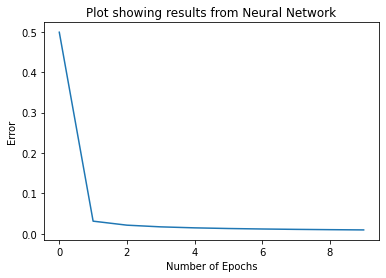

In [ ]:
plt.xlabel('Number of Epochs')
plt.ylabel('Error')
plt.title('Plot showing results from Neural Network')
plt.plot(error)
plt.show()

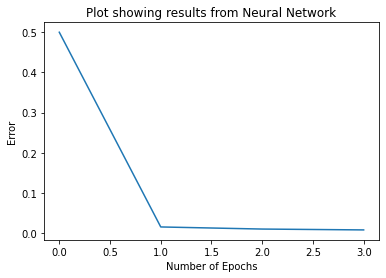

In [ ]:
plt.xlabel('Number of Epochs')
plt.ylabel('Error')
plt.title('Plot showing results from Neural Network')
plt.plot(error)
plt.show()

#### Compearing the outputs and the predictions

In [ ]:
outputs

array([[0],
       [1],
       [1],
       [0]])

In [ ]:
output_layer

array([[0.0105802 ],
       [0.9826343 ],
       [0.98124727],
       [0.02222762]])

#### * We see that our neural network was able to get values close to the actual values from the results. 
#### * This shows that our neural network can handle the complexity of the XOR operator dataset.

* Let us see the updated weights. These are the weights we will require if we want to make future predictions

In [ ]:
weights_0

array([[-0.04578885, -5.45125419, -1.01868082],
       [ 1.04772434, -5.25578328, -0.5958262 ]])

In [ ]:
weights_1

array([[-14.93268248],
       [-37.16040415],
       [ 43.01681387]])

In [ ]:
# This function accepts an instance of a dataset

def calculate_output(instance):
    #input to hidden layer
    hidden_layer = sigmoid(np.dot(instance, weights_0))
    #hidden to output layer
    output_layer = sigmoid(np.dot(hidden_layer, weights_1))
    return output_layer[0]

In [ ]:
round(calculate_output(np.array([0, 0])))

0

In [ ]:
round(calculate_output(np.array([0, 1])))

1

In [ ]:
round(calculate_output(np.array([1, 0])))

1

In [ ]:
round(calculate_output(np.array([1, 1])))

0